# 02. 데이터 분석 (KEY PAPER 단순화 적용)

KEY PAPER(Qurat Ul Ain & Rather, 2025)의 SHAP 통합 ML 프레임워크를 건설업 산업재해 데이터에 적용.

**분석 흐름**: EDA → LR (A/B 분리) → 조절효과 → ML 4모델 비교 → SHAP

In [1]:
# 필요 패키지 (미설치 시 주석 해제)
# !pip install imbalanced-learn xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import platform
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
if platform.system() == 'Windows':
    mpl.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    mpl.rc('font', family='AppleGothic')
mpl.rcParams['axes.unicode_minus'] = False

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedKFold, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import statsmodels.api as sm
from scipy import stats
import shap

df = pd.read_csv('../data/전처리_최종.csv')
print(f'데이터: {df.shape}')

데이터: (1375, 17)


In [2]:
# 변수 그룹 정의
GROUP_A = ['안전조직수준', '위원회수준', '인증보유']
GROUP_B = ['위험성평가수준', '교육훈련도움', '정리정돈상태', '작업중지권', '작업반장기여']
MODERATORS = ['전문지도', '고용노동부감독', '안전보건공단지원']
CONTROLS = ['공사규모', '발주처', '기성공정률', '공사종류', '외국인비율']
TARGET = '사고발생'

# 표준화 (추론 LR 전용 - df_s, X)
all_vars = GROUP_A + GROUP_B + MODERATORS + CONTROLS
scaler = StandardScaler()
df_s = df.copy()
df_s[all_vars] = scaler.fit_transform(df[all_vars])
y = df_s[TARGET]

# 추론 LR용 데이터 (표 4-A/B, 5-A/B는 df_s 사용, 불변)
FEATURES = [c for c in df.columns if c != TARGET]
X = pd.DataFrame(scaler.fit_transform(df[FEATURES]), columns=FEATURES)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ML 전용 원본 데이터 (SMOTENC는 범주형 원값 보존 필요 → 표준화 전 split)
CATEGORICAL_COLS = ['안전조직수준', '위원회수준', '인증보유', '위험성평가수준',
                    '전문지도', '고용노동부감독', '안전보건공단지원',
                    '공사규모', '발주처', '공사종류']
X_raw = df[FEATURES].copy()
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
cat_idx = [X_raw.columns.get_loc(c) for c in CATEGORICAL_COLS]

print(f'Train: {X_tr.shape}, Test: {X_te.shape}')
print(f'ML raw Train: {X_tr_raw.shape}, ML raw Test: {X_te_raw.shape}')
print(f'범주형 인덱스: {cat_idx}')

Train: (1100, 16), Test: (275, 16)
ML raw Train: (1100, 16), ML raw Test: (275, 16)
범주형 인덱스: [0, 1, 2, 3, 8, 9, 10, 11, 12, 14]


---
## Phase 1. 탐색적 데이터 분석 (EDA)

KEY PAPER Fig 2, Fig 3 대응

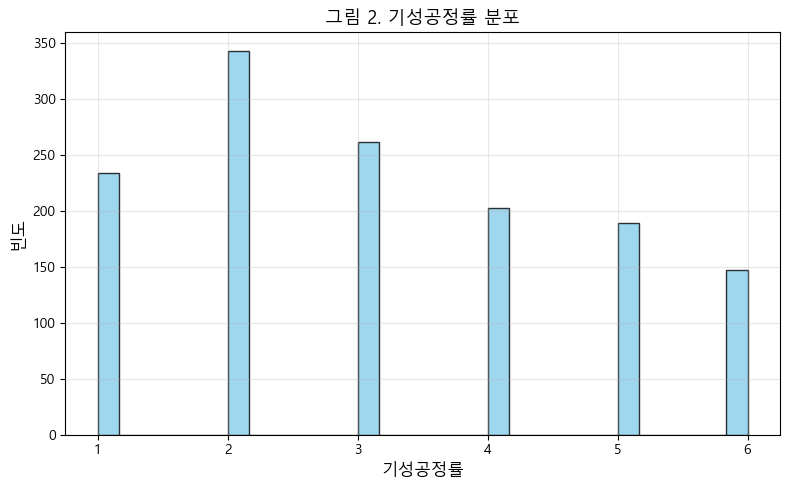

In [3]:
# 그림 2: 기성공정률 분포 (KEY PAPER의 BMI 분포 대응)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['기성공정률'], bins=30, color='skyblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('기성공정률', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.set_title('그림 2. 기성공정률 분포', fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/fig2_기성공정률분포.png', dpi=120, bbox_inches='tight')
plt.show()

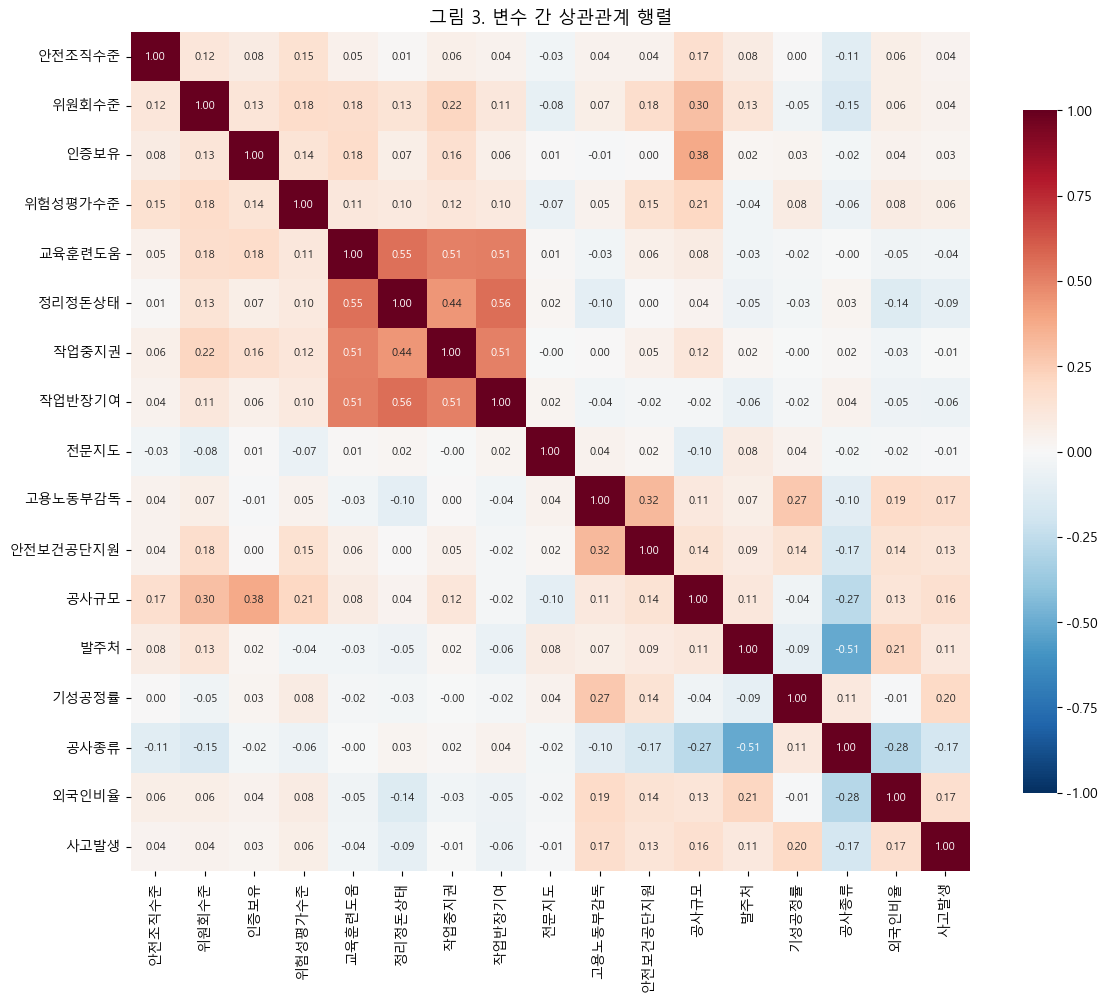

In [4]:
# 그림 3: 상관관계 히트맵 (KEY PAPER Fig 3 대응)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'shrink':0.8}, annot_kws={'size':8})
ax.set_title('그림 3. 변수 간 상관관계 행렬', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/fig3_상관관계.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 2. 로지스틱 회귀 분석 (A/B 그룹 분리)

KEY PAPER Table 4 확장. A 그룹(내부관리)과 B 그룹(현장행동)을 분리하여 각각 LR 적합.

In [5]:
def fit_table(X, y):
    m = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
    t = pd.DataFrame({
        '계수': m.params.round(4), '표준오차': m.bse.round(4),
        '오즈비(OR)': np.exp(m.params).round(4),
        '95%CI_하한': np.exp(m.conf_int()[0]).round(4),
        '95%CI_상한': np.exp(m.conf_int()[1]).round(4),
        'p값': m.pvalues.round(4),
        '유의도': ['***' if p<.001 else '**' if p<.01 else '*' if p<.05 else '' for p in m.pvalues]
    })
    t.index.name = '변수명'
    return m, t

In [6]:
# 표 4-A: A 그룹 LR
model_A, table_4A = fit_table(df_s[GROUP_A + MODERATORS + CONTROLS], y)
print('=== 표 4-A: A 그룹 (내부 안전관리) ===')
table_4A

=== 표 4-A: A 그룹 (내부 안전관리) ===


,계수,표준오차,오즈비(OR),95%CI_하한,95%CI_상한,p값,유의도
변수명,,,,,,,
const,-1.0603,0.0673,0.3464,0.3036,0.3952,0.0000,***
안전조직수준,-0.0081,0.0756,0.9920,0.8553,1.1504,0.9150,
위원회수준,-0.0565,0.0693,0.9450,0.8251,1.0825,0.4145,
인증보유,-0.0733,0.0695,0.9293,0.8110,1.0649,0.2917,
전문지도,-0.0514,0.0650,0.9499,0.8362,1.0790,0.4289,
고용노동부감독,0.1581,0.0700,1.1713,1.0211,1.3436,0.0240,*
안전보건공단지원,0.1154,0.0767,1.1223,0.9656,1.3045,0.1326,
공사규모,0.3020,0.0754,1.3526,1.1669,1.5679,0.0001,***
발주처,0.0851,0.0748,1.0888,0.9403,1.2608,0.2555,


In [7]:
# 표 4-B: B 그룹 LR
model_B, table_4B = fit_table(df_s[GROUP_B + MODERATORS + CONTROLS], y)
print('=== 표 4-B: B 그룹 (현장 안전 행동) ===')
table_4B

=== 표 4-B: B 그룹 (현장 안전 행동) ===


,계수,표준오차,오즈비(OR),95%CI_하한,95%CI_상한,p값,유의도
변수명,,,,,,,
const,-1.0665,0.0676,0.3442,0.3015,0.3930,0.0000,***
위험성평가수준,0.0333,0.0735,1.0339,0.8951,1.1942,0.6507,
교육훈련도움,-0.0189,0.0825,0.9813,0.8348,1.1535,0.8189,
정리정돈상태,-0.1726,0.0820,0.8415,0.7165,0.9882,0.0354,*
작업중지권,0.0444,0.0781,1.0454,0.8970,1.2183,0.5698,
작업반장기여,-0.0135,0.0820,0.9866,0.8402,1.1585,0.8692,
전문지도,-0.0435,0.0651,0.9574,0.8428,1.0877,0.5039,
고용노동부감독,0.1481,0.0703,1.1597,1.0104,1.3310,0.0351,*
안전보건공단지원,0.1133,0.0767,1.1200,0.9637,1.3017,0.1396,


### 핵심 발견
- **정리정돈상태**: OR=0.84, p=0.035 → 보호효과 (사고 확률 약 16% 감소)
- 통제변수(공사규모, 기성공정률, 외국인비율)가 강한 양의 효과

---
## Phase 3. 조절효과 분석 (RQ 핵심)

KEY PAPER의 BMI×흡연 상호작용(1쌍)을 본 연구 RQ에 맞게 24쌍으로 확장.
- A 그룹 × 조절변수 3종 = 9쌍
- B 그룹 × 조절변수 3종 = 15쌍 (대조용)

In [8]:
def fit_logit(X, y):
    return sm.Logit(y, sm.add_constant(X)).fit(disp=0)

def lr_test(full, reduced):
    chi2 = 2 * (full.llf - reduced.llf)
    df_diff = full.df_model - reduced.df_model
    return chi2, df_diff, 1 - stats.chi2.cdf(chi2, df_diff)

def run_moderation(group, baseline):
    results = []
    for mod in MODERATORS:
        X_int = df_s[group + MODERATORS + CONTROLS].copy()
        for v in group:
            X_int[f'{v}×{mod}'] = df_s[v] * df_s[mod]
        m = fit_logit(X_int, y)
        _, _, p_lr = lr_test(m, baseline)
        for v in group:
            term = f'{v}×{mod}'
            coef = m.params[term]; pv = m.pvalues[term]; ci = m.conf_int().loc[term]
            results.append({
                '조절변수': mod, '주효과변수': v, '계수': round(coef,4),
                '오즈비(OR)': round(np.exp(coef),4),
                '95%신뢰구간': f"[{np.exp(ci[0]):.3f}, {np.exp(ci[1]):.3f}]",
                'p값': round(pv,4),
                '유의도': '***' if pv<.001 else '**' if pv<.01 else '*' if pv<.05 else '',
                '집합검정_p값': round(p_lr,4),
            })
    return pd.DataFrame(results)

In [9]:
# 표 5-A: A 그룹 × 조절효과
m_A = fit_logit(df_s[GROUP_A + MODERATORS + CONTROLS], y)
t5a = run_moderation(GROUP_A, m_A)
print('=== 표 5-A: A 그룹 × 조절변수 상호작용 ===')
t5a

=== 표 5-A: A 그룹 × 조절변수 상호작용 ===


,조절변수,주효과변수,계수,오즈비(OR),95%신뢰구간,p값,유의도,집합검정_p값
0,전문지도,안전조직수준,-0.1381,0.8710,"[0.736, 1.031]",0.1093,,0.1929
1,전문지도,위원회수준,-0.0296,0.9708,"[0.853, 1.104]",0.6527,,0.1929
2,전문지도,인증보유,0.0835,1.0871,"[0.958, 1.233]",0.1946,,0.1929
3,고용노동부감독,안전조직수준,0.1104,1.1167,"[0.936, 1.332]",0.2191,,0.0178
4,고용노동부감독,위원회수준,-0.1428,0.8669,"[0.757, 0.992]",0.0382,*,0.0178
5,고용노동부감독,인증보유,0.1526,1.1649,"[1.023, 1.327]",0.0215,*,0.0178
6,안전보건공단지원,안전조직수준,0.0586,1.0604,"[0.935, 1.202]",0.3609,,0.6652
7,안전보건공단지원,위원회수준,0.0484,1.0495,"[0.918, 1.200]",0.4796,,0.6652
8,안전보건공단지원,인증보유,-0.0387,0.9621,"[0.834, 1.110]",0.5964,,0.6652


In [10]:
# 표 5-B: B 그룹 × 조절효과 (대조용)
m_B = fit_logit(df_s[GROUP_B + MODERATORS + CONTROLS], y)
t5b = run_moderation(GROUP_B, m_B)
print('=== 표 5-B: B 그룹 × 조절변수 상호작용 ===')
t5b

=== 표 5-B: B 그룹 × 조절변수 상호작용 ===


,조절변수,주효과변수,계수,오즈비(OR),95%신뢰구간,p값,유의도,집합검정_p값
0,전문지도,위험성평가수준,-0.1115,0.8945,"[0.779, 1.027]",0.1127,,0.1375
1,전문지도,교육훈련도움,0.0613,1.0632,"[0.898, 1.259]",0.4766,,0.1375
2,전문지도,정리정돈상태,0.1454,1.1565,"[0.983, 1.360]",0.0788,,0.1375
3,전문지도,작업중지권,0.0274,1.0278,"[0.882, 1.197]",0.7248,,0.1375
4,전문지도,작업반장기여,-0.1428,0.8669,"[0.741, 1.014]",0.0749,,0.1375
5,고용노동부감독,위험성평가수준,-0.0931,0.9111,"[0.786, 1.056]",0.2173,,0.4148
6,고용노동부감독,교육훈련도움,0.0418,1.0427,"[0.884, 1.230]",0.6202,,0.4148
7,고용노동부감독,정리정돈상태,0.1266,1.1349,"[0.962, 1.338]",0.1324,,0.4148
8,고용노동부감독,작업중지권,-0.0182,0.9819,"[0.839, 1.149]",0.8205,,0.4148
9,고용노동부감독,작업반장기여,-0.1085,0.8972,"[0.760, 1.059]",0.1994,,0.4148


In [11]:
# 조절효과 종합
print('=== 조절효과 종합 ===')
for mod in MODERATORS:
    a_sig = sum(1 for _,r in t5a.iterrows() if r['조절변수']==mod and r['p값']<0.05)
    b_sig = sum(1 for _,r in t5b.iterrows() if r['조절변수']==mod and r['p값']<0.05)
    marker = ' ★' if a_sig > 0 or b_sig > 0 else ''
    print(f'  {mod}: A={a_sig}/{len(GROUP_A)}, B={b_sig}/{len(GROUP_B)}{marker}')

=== 조절효과 종합 ===
  전문지도: A=0/3, B=0/5
  고용노동부감독: A=2/3, B=0/5 ★
  안전보건공단지원: A=0/3, B=0/5


### RQ에 대한 답
- **고용노동부감독만** A 그룹에 유의한 조절효과 (p=0.018)
  - 인증보유 × 감독: OR=1.165, p=0.022
  - 위원회수준 × 감독: OR=0.867, p=0.038
- **B 그룹: 15개 전부 무의** → 가설 지지

---
## Phase 4. 머신러닝 모델 비교

KEY PAPER Table 6~9 대응. **SMOTENC(학습셋만)** 로 클래스 불균형 처리 후 LR / RF / XGBoost / LightGBM 4모델 비교.
- 테스트셋은 원본 분포(약 28% 양성) 유지 → 데이터 누수 방지.
- 교차검증도 `ImbPipeline` 내부에 SMOTENC를 넣어 fold별 학습 fold에만 리샘플링.

In [12]:
# SMOTENC 적용 (학습셋에만) — 테스트셋은 원본 분포 유지
smote = SMOTENC(categorical_features=cat_idx, random_state=42)
X_tr_res, y_tr_res = smote.fit_resample(X_tr_raw, y_tr_raw)
print(f'원본 train: {X_tr_raw.shape}, 양성비 {y_tr_raw.mean():.3f}')
print(f'SMOTENC train: {X_tr_res.shape}, 양성비 {y_tr_res.mean():.3f}')

# LR 전용 표준화 (SMOTENC 후 학습셋에 fit → 테스트셋에 transform)
scaler_lr = StandardScaler().fit(X_tr_res)
X_tr_res_sc = scaler_lr.transform(X_tr_res)
X_te_sc = scaler_lr.transform(X_te_raw)

models = {
    '로지스틱회귀': LogisticRegression(max_iter=1000, random_state=42),
    '랜덤포레스트': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
trained, probs, preds, results, cv_stats = {}, {}, {}, {}, {}

for name, m in models.items():
    # 1) 테스트셋 평가: SMOTENC 학습셋으로 fit
    if name == '로지스틱회귀':
        m.fit(X_tr_res_sc, y_tr_res)
        yp = m.predict(X_te_sc); yprob = m.predict_proba(X_te_sc)[:, 1]
    else:
        m.fit(X_tr_res, y_tr_res)
        yp = m.predict(X_te_raw); yprob = m.predict_proba(X_te_raw)[:, 1]

    trained[name] = m; preds[name] = yp; probs[name] = yprob

    # 2) CV: ImbPipeline 내부에 SMOTENC → 각 fold 학습 fold에만 적용 (검증 fold는 원본)
    if name == '로지스틱회귀':
        pipe = ImbPipeline([
            ('smote', SMOTENC(categorical_features=cat_idx, random_state=42)),
            ('sc', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, random_state=42)),
        ])
    elif name == '랜덤포레스트':
        pipe = ImbPipeline([
            ('smote', SMOTENC(categorical_features=cat_idx, random_state=42)),
            ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)),
        ])
    elif name == 'XGBoost':
        pipe = ImbPipeline([
            ('smote', SMOTENC(categorical_features=cat_idx, random_state=42)),
            ('clf', XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0, n_jobs=-1)),
        ])
    else:  # LightGBM
        pipe = ImbPipeline([
            ('smote', SMOTENC(categorical_features=cat_idx, random_state=42)),
            ('clf', LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)),
        ])
    cv_auc = cross_val_score(pipe, X_raw, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_stats[name] = (cv_auc.mean(), cv_auc.std())

    results[name] = {
        '모델명': name,
        '정확도': round(accuracy_score(y_te_raw, yp), 4),
        '정밀도': round(precision_score(y_te_raw, yp, zero_division=0), 4),
        '재현율': round(recall_score(y_te_raw, yp, zero_division=0), 4),
        'F1점수': round(f1_score(y_te_raw, yp, zero_division=0), 4),
        'AUC': round(roc_auc_score(y_te_raw, yprob), 4),
        '교차검증AUC_평균': round(cv_auc.mean(), 4),
        '교차검증AUC_표준편차': round(cv_auc.std(), 4),
    }

tbl9 = pd.DataFrame(list(results.values()))
print('=== 표 9: 모델 비교 (SMOTENC 적용) ===')
display(tbl9)

# CSV 저장 (통합)
OUT = Path('../results/tables')
tbl9.to_csv(OUT / 'table9_모델비교.csv', index=False, encoding='utf-8-sig')

# 단일 모델 표 저장 (table9의 row-subset, 동일 스키마)
for model_name, file_name in [
    ('랜덤포레스트', 'table6_RF성능.csv'),
    ('XGBoost', 'table7_XGBoost성능.csv'),
    ('LightGBM', 'table8_LightGBM성능.csv'),
]:
    tbl9[tbl9['모델명'] == model_name].to_csv(
        OUT / file_name, index=False, encoding='utf-8-sig'
    )

# 구 파일 정리 (SVM/GBM)
for old in ['table7_SVM성능.csv', 'table8_GBM성능.csv']:
    Path(OUT / old).unlink(missing_ok=True)
print('\nCSV 저장 및 구 파일 정리 완료')

원본 train: (1100, 16), 양성비 0.285
SMOTENC train: (1574, 16), 양성비 0.500


=== 표 9: 모델 비교 (SMOTENC 적용) ===


,모델명,정확도,정밀도,재현율,F1점수,AUC,교차검증AUC_평균,교차검증AUC_표준편차
0,로지스틱회귀,0.6364,0.4113,0.6538,0.5050,0.6828,0.6814,0.0489
1,랜덤포레스트,0.6836,0.4563,0.6026,0.5193,0.6967,0.7114,0.0454
2,XGBoost,0.6800,0.4500,0.5769,0.5056,0.7103,0.6858,0.0395
3,LightGBM,0.6873,0.4592,0.5769,0.5114,0.7055,0.6966,0.0419



CSV 저장 및 구 파일 정리 완료


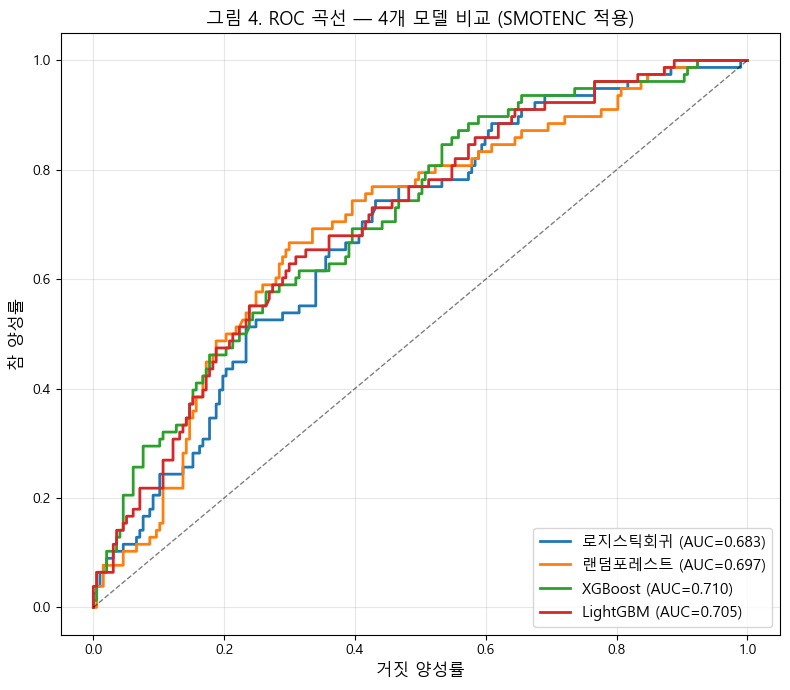

In [13]:
# 그림 4: ROC 곡선 (셀 18에서 학습된 확률 재사용 - 재학습/누수 없음)
fig, ax = plt.subplots(figsize=(8, 7))
for name in models.keys():
    yprob = probs[name]
    fpr, tpr, _ = roc_curve(y_te_raw, yprob)
    auc_val = roc_auc_score(y_te_raw, yprob)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('거짓 양성률', fontsize=12)
ax.set_ylabel('참 양성률', fontsize=12)
ax.set_title('그림 4. ROC 곡선 — 4개 모델 비교 (SMOTENC 적용)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/fig4_ROC곡선.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Phase 5. SHAP 분석

KEY PAPER SHAP TreeExplainer 대응. **RandomForest** 기반 변수 중요도 해석 (CV AUC 최고·최소 분산 모델, Phase 4에서 SMOTENC 학습셋으로 fit된 모델 재사용).

In [14]:
# RandomForest 기반 SHAP (CV AUC 최고·최소 분산 모델, 셀 18에서 SMOTENC 학습셋에 fit된 모델 재사용)
rf_for_shap = trained['랜덤포레스트']

explainer = shap.TreeExplainer(rf_for_shap)
sv = explainer.shap_values(X_te_raw)
if isinstance(sv, list): sv = sv[1]
elif sv.ndim == 3: sv = sv[:, :, 1]
print(f'SHAP values shape: {sv.shape}')

SHAP values shape: (275, 16)


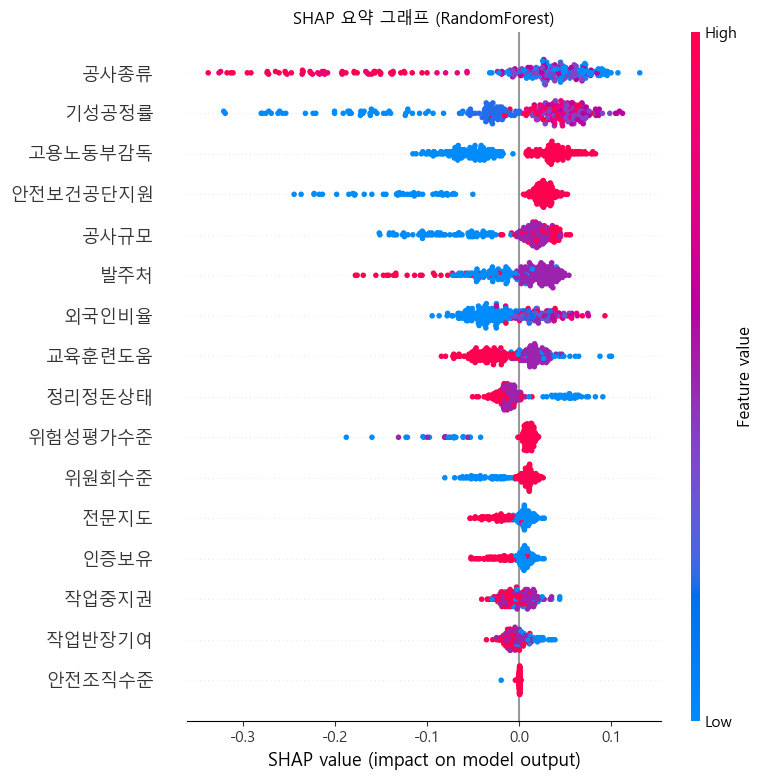

In [15]:
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_te_raw, show=False, max_display=16)
plt.title('SHAP 요약 그래프 (RandomForest)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/fig5_SHAP요약.png', dpi=120, bbox_inches='tight')
plt.show()

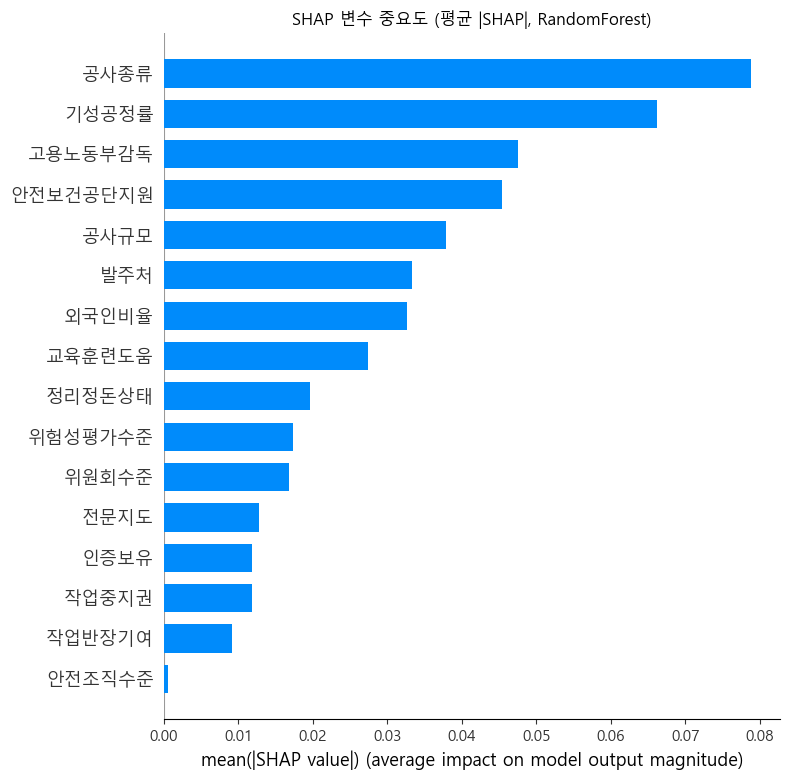

In [16]:
# SHAP Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_te_raw, plot_type='bar', show=False, max_display=16)
plt.title('SHAP 변수 중요도 (평균 |SHAP|, RandomForest)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/fig6_SHAP중요도.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# SHAP 중요도 표
imp = pd.DataFrame({
    '변수명': X_te_raw.columns,
    '평균|SHAP|': np.abs(sv).mean(axis=0).round(4),
}).sort_values('평균|SHAP|', ascending=False).reset_index(drop=True)
imp['순위'] = imp.index + 1

imp.to_csv('../results/tables/table_SHAP중요도.csv', index=False, encoding='utf-8-sig')

print('=== SHAP 변수 중요도 Top-10 ===')
imp.head(10)

=== SHAP 변수 중요도 Top-10 ===


,변수명,평균|SHAP|,순위
0,공사종류,0.0788,1
1,기성공정률,0.0662,2
2,고용노동부감독,0.0476,3
3,안전보건공단지원,0.0454,4
4,공사규모,0.0379,5
5,발주처,0.0333,6
6,외국인비율,0.0327,7
7,교육훈련도움,0.0274,8
8,정리정돈상태,0.0196,9
9,위험성평가수준,0.0174,10


---
## 종합 결론

| 발견 | 의미 |
|---|---|
| 정리정돈상태 보호효과 (OR=0.84, p=0.035) | 즉시 개선 가능한 행동 변수가 사고를 줄임 |
| 감독 × A 그룹 조절효과 (p=0.018) | 외부기관 중 감독만, 제도 차원에만 작동 |
| 통제변수·외부기관이 SHAP 상위 7위 독점 | 사업장 구조적 특성(공사종류·기성공정률·공사규모·외국인비율)과 외부기관(감독·공단지원)이 사고에 가장 강한 영향 |
| SMOTENC 적용 후 트리 계열(XGB·LGBM·RF)이 LR보다 AUC 소폭 우위 | 비선형 상호작용 포착 이득이 존재하나 데이터 자체는 선형성이 강함 |
| SMOTENC 학습셋 한정 적용 | 테스트셋 분포 보존 → 재현율 큰 폭 상승(LR 0.17 → 0.65)과 정밀도 하락을 동반하는 전형적 불균형 처리 효과 |